In [1]:
import os
os.chdir('..')
from gpu_management import set_gpus
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
set_gpus(1, forcing=True)

In [7]:
from data import DL17Lands, collate_cards, make_reverse_dict, make_graph, make_adjacency
from card_utils import get_card_image
from data_types import Sets
from nlp import Gemma

dataloader = DL17Lands('FDN')
nlp_processor = Gemma()
cards = collate_cards(dataloader, nlp_processor, False)
cards_prompted = collate_cards(dataloader, nlp_processor, False, prompt="task: Magic the Gathering card selection in a draft | card: ")

Loading FDN
-----------
Loading card data: 0.000079s
Making extension dataframe: 0.284374s
##################################################


In [3]:
import torch
import numpy as np

h = torch.from_numpy(np.array(cards.textual_features))
h_prompted = torch.from_numpy(np.array(cards_prompted.textual_features))
sims = nlp_processor.model.similarity(h, h)
sims_prompted = nlp_processor.model.similarity(h_prompted, h_prompted)
sims

tensor([[1.0000, 0.4454, 0.4901,  ..., 0.3632, 0.4727, 0.5487],
        [0.4454, 1.0000, 0.4965,  ..., 0.4254, 0.4591, 0.4951],
        [0.4901, 0.4965, 1.0000,  ..., 0.4271, 0.4952, 0.4614],
        ...,
        [0.3632, 0.4254, 0.4271,  ..., 1.0000, 0.5193, 0.4127],
        [0.4727, 0.4591, 0.4952,  ..., 0.5193, 1.0000, 0.5381],
        [0.5487, 0.4951, 0.4614,  ..., 0.4127, 0.5381, 1.0000]])

In [9]:
id_map = make_reverse_dict(cards.card_id, 1)
graph_type = 'knn'
graph_density = 0.1
graph = make_graph(
    nlp_processor.model.similarity(h, h).numpy(), #type: ignore
    density=graph_density,
    local=graph_type=='knn'
)
adjacency = make_adjacency(graph, cards.card_id.shape[0])

sets = Sets(
    card_ids=id_map[cards.card_id],
    set_size=cards.card_id.shape[0],
    pack_size=dataloader.pack_size,
    graph=graph,
    adjacency=adjacency
)

In [10]:
dataloader.cards[1]['oracle'].item()

'[NAME] Arahbo, the First Fang | [MC] {2}{W} | [CMC] 3 | [COLOR] W | [RARITY] rare | [TYPE] Legendary Creature | [SUBTYPE] Cat Avatar | [P/T] 2/2 | [EFFECTS] Other Cats you control get +1/+1. <NL> Whenever Arahbo or another nontoken Cat you control enters, create a 1/1 white Cat creature token.'

In [12]:
from sklearn.manifold import TSNE

sims_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=5, random_state=42).fit_transform(h.numpy())
sims_prompted_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=5, random_state=42).fit_transform(np.array(cards_prompted.textual_features))
sims_embedded

array([[-25.055782  , -22.177404  ],
       [ 41.747242  , -22.81201   ],
       [ 28.453623  , -44.18882   ],
       [ 39.440845  , -22.47352   ],
       [ -1.6275009 ,  30.056038  ],
       [ 38.77891   , -18.827414  ],
       [ 25.875708  ,  24.545414  ],
       [  9.692424  ,  -6.1947336 ],
       [  8.782391  , -47.114697  ],
       [-10.735743  ,   3.993967  ],
       [  8.373518  , -45.79038   ],
       [ 32.524708  , -23.237328  ],
       [-15.946718  ,  17.67334   ],
       [ 30.524055  , -23.374979  ],
       [ 43.48743   , -22.447475  ],
       [ 38.745243  , -21.60564   ],
       [ 10.528722  , -44.58368   ],
       [-11.836299  ,   9.982755  ],
       [-15.463042  ,   9.777597  ],
       [-17.833868  ,  31.51968   ],
       [ 39.966167  , -24.72684   ],
       [-24.666153  ,  -8.286649  ],
       [ 17.240732  , -29.74039   ],
       [ 19.769445  ,  14.846485  ],
       [ 15.849001  , -35.296318  ],
       [ 30.743235  ,  -9.788895  ],
       [  5.5944667 , -46.80603   ],
 

In [13]:
import polars as pl

cards.card_id
colors = np.array([dataloader.cards.filter(pl.col('id') == cards.card_id[i])['color_identity'].item() for i in range(cards.card_id.shape[0])])
colors

array([None, 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U',
       'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U',
       'U', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'R',
       'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R',
       'R', 'R', 'R', 'R', 'R', 'R', 'G', 'G', 'G', 'G', 'G', 'G', 'G',
       'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'G', 'BR', 'GW', 'GR',
       'BU', 'BW', 'BW', 'GU', 'UW', 'RU', 'BR', 'BG', 'GU', None, None,
       None, None, None, None, None, 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'U', 'U', 'U', 'U',
       'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U', 'U',
       'U', 'U', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B

<Axes: >

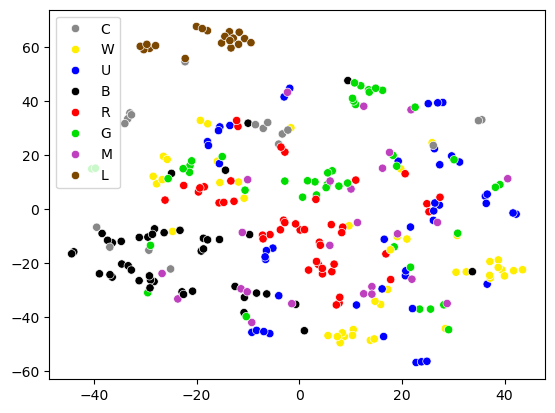

In [14]:
import seaborn as sns

palette = {
    'W': '#FFEE00',
    'U': '#0000FF',
    'B': '#000000',
    'R': '#FF0000',
    'G': '#00DD00',
    'L': '#7C4700',
    'C': '#888888',
    'M': '#BF40BF',
}
for i in range(len(colors)):
    if 'Land' in dataloader.cards.filter(pl.col('id') == cards.card_id[i])['types'].item():
        colors[i] = 'L'
    elif dataloader.cards.filter(pl.col('id') == cards.card_id[i])['color_identity'].item() is None:
        colors[i] = 'C'
    elif len(dataloader.cards.filter(pl.col('id') == cards.card_id[i])['color_identity'].item()) > 1:
        colors[i] = 'M'
sns.scatterplot(x=sims_embedded[:,0], y=sims_embedded[:,1], hue=colors, palette=palette)

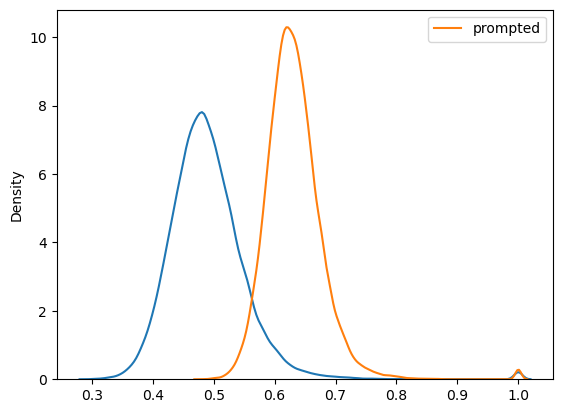

In [17]:
import matplotlib.pyplot as plt

sns.kdeplot(data=sims.flatten().numpy())
sns.kdeplot(data=sims_prompted.flatten().numpy(), label='prompted')
plt.legend()

In [18]:
import networkx as nx

def make_graph_knn(sims, density=0.2):
    n = sims.shape[0]
    k = int((n-1) * density)
    U = []
    V = []
    for u in range(n):
        U.extend([u] * (k+1))
        V.extend(np.argsort(sims[u])[-k-1:])
    return U, V

def make_graph_global(sims, density=0.2):
    n = sims.shape[0]
    values = sims.flatten()
    values.sort()
    values = values[:-n]
    limit = values[-int(len(values)*density)]
    adj_matrix = sims > limit
    print(np.argwhere(adj_matrix).T.shape)
    return np.argwhere(adj_matrix).T

def make_graph(sims, density=0.1, local=False):
    if local:
        return make_graph_knn(sims, density)
    return make_graph_global(sims, density)

def adj_list_to_digraph(sims, U, V):
    n = sims.shape[0]
    G = nx.DiGraph()
    G.add_nodes_from([(i, {'name': dataloader.cards.filter(pl.col('id') == cards.card_id[i])['name'].item(), 'color': palette[colors[i]]}) for i in range(n)])
    for u, v in zip(U, V):
        if u == v: continue
        G.add_edge(u, v, weight=sims[u][v])
    return G

U, V = make_graph(sims.numpy(), density=0.02, local=True)
G = adj_list_to_digraph(sims.numpy(), U, V)

In [19]:
from yfiles_jupyter_graphs import GraphWidget
from typing import Dict

def node_label_mapping(index: int, node: Dict):
    return node['properties']['name']
def edge_label_mapping(index: int, edge: Dict):
    return f'{edge['properties']['weight']:.2}'

w = GraphWidget(graph=G)
w.set_node_label_mapping(node_label_mapping)
w.set_edge_label_mapping(edge_label_mapping)
w.set_node_color_mapping(lambda node: node['properties']['color'])
w.show()

GraphWidget(layout=Layout(height='800px', width='100%'))